In [1]:
import operator
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

from deap import base, creator, tools, gp, algorithms

In [5]:
from IPython.display import display, Javascript
display(Javascript('''
    document.querySelectorAll('.prompt').forEach(el => el.style.display = 'none');
'''))
from IPython.display import display, HTML
display(HTML("""
    <style>
        .jp-Notebook .jp-modified {
            border-left: none !important;
        }
    </style>
"""))


<IPython.core.display.Javascript object>

In [2]:
# Safe division to avoid division-by-zero errors
def safeDiv(a, b):
    return a / b if b != 0 else 1  # Prevents division by zero

    hkjhkh

In [3]:
# Conditional if operator
def if_operator(condition, output_true, output_false):
    return output_true if condition > 0 else output_false

# Classification function based on fixed thresholds (Algorithm 1)
def classify_output(y_pred, mode):
    y_pred = np.clip(y_pred, -1, 1)  # Clip to avoid overflow in sigmoid
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))  # Sigmoid function

    if mode == "binary":
        return (y_pred_sigmoid > 0.5).astype(int)  # Binary classification threshold

    elif mode == "multiclass":
        thresholds = [0.20, 0.40, 0.60, 0.80]  # Multi-class thresholds
        return np.digitize(y_pred_sigmoid, thresholds)

    # elif mode == "multistage":
    #     thresholds = [0.20, 0.80]  # Multi-stage thresholds
    #     return np.digitize(y_pred_sigmoid, threshold

In [4]:
from sklearn.utils.class_weight import compute_class_weight

print("\n Evaluating GP Individual...\n")

# GP evaluation function following Algorithm 1
def evalGP(individual, X_train, y_train, mode):
    
    
    # Compile GP tree into a function f(x)
    func = gp.compile(expr=individual, pset=pset)

    # Apply f(x) to each instance in the training set
    y_pred = np.array([func(*x) for x in X_train])

    # Apply sigmoid to constrain outputs between 0 and 1
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))

    # Classify outputs using fixed thresholds per mode
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])

    # Ensure predictions match valid class labels using y_train (not y_test)
    valid_classes = np.unique(y_train)  # Get valid classes from training labels
    y_pred_class = np.array([c if c in valid_classes else np.random.choice(valid_classes) for c in y_pred_class])

    # Compute class weights
    class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    weights_dict = {cls: weight for cls, weight in zip(np.unique(y_train), class_weights)}
    
    # Apply weights to accuracy calculation
    fitness = balanced_accuracy_score(y_train, y_pred_class, sample_weight=[weights_dict[y] for y in y_train])

    return (fitness,)


 Evaluating GP Individual...



In [5]:
# Function to run GP evolution
def run_gp(X_train, y_train, mode, population_size=10, ngen=50, cxpb=0.8, mutpb=0.19):
    print(f"\n>> Starting GP Evolution for {mode.upper()} Classification...\n")
    
    # Initialize population
    pop = toolbox.population(n=population_size)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f">> Population initialized with {population_size} individuals.")
    print(f">> Running evolution for {ngen} generations...\n")

    for gen in range(ngen):
        print(f">>> Generation {gen+1}/{ngen}")

        # Evaluate fitness of the population
        fitnesses = list(map(toolbox.evaluate, pop))
        for ind, fit in zip(pop, fitnesses):
            ind.fitness.values = fit

        # Print fitness of best individual in the generation
        best_ind = max(pop, key=lambda ind: ind.fitness.values[0])
        print(f">>> Best Individual (Gen {gen+1}): {best_ind}, Fitness: {best_ind.fitness.values[0]:.4f}")

        # Selection
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values, child2.fitness.values
        print(">>> Crossover Applied")

        # Apply mutation
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        print(">>> Mutation Applied")

        # Replace old population with new offspring
        pop[:] = offspring

        # Evaluate fitness again
        invalid_ind = [ind for ind in pop if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Print best fitness in the generation
        best_gen_fitness = max(ind.fitness.values[0] for ind in pop)
        print(f">>> Best Fitness (Gen {gen+1}): {best_gen_fitness:.4f}")

    print("\n>> Evolution Completed!")

    # Retrieve best individual from Hall of Fame
    best_individual = hof[0] if len(hof) > 0 else max(pop, key=lambda ind: ind.fitness.values[0])
    print("\n>> Best GP Individual After Evolution:")
    print(best_individual)

    return best_individual, stats

In [6]:
# Plot confusion matrix using seaborn
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

In [7]:
# Evaluate the best GP individual on test data and plot confusion matrix
def evaluate_best_model(best_individual, X_test, y_test, mode):
    func = gp.compile(expr=best_individual, pset=pset)
    y_pred = np.array([func(*x) for x in X_test])
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])
    acc = balanced_accuracy_score(y_test, y_pred_class)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_class))
    plot_confusion_matrix(y_test, y_pred_class, f"Confusion Matrix ({mode})")
    
    return acc

In [8]:
# Plot evolution progress over generations
def plot_evolution(stats, title):
    gens = range(len(stats))
    avg_acc = stats.select("avg")
    max_acc = stats.select("max")
    plt.figure(figsize=(8, 5))
    plt.plot(gens, avg_acc, label="Average Fitness", linestyle="--", marker="o")
    plt.plot(gens, max_acc, label="Max Fitness", marker="s")
    
    plt.xlabel("Generation")
    plt.ylabel("Balanced Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [9]:
# Simple alert system for multistage classification
def alert_system(best_individual, X_test):
    func = gp.compile(expr=best_individual, pset=pset)
    y_pred = np.array([func(*x) for x in X_test])
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
    y_pred_class = np.array([classify_output(val, "multistage") for val in y_pred_sigmoid])
    
    alert_labels = {
        0: "Normal Traffic",
        1: "Reconnaissance Detected!",
        2: "Foothold Establishment / Lateral Movement Detected!",
        3: "Data Exfiltration Detected! Possible Breach!"
    }
    print("\nReal-Time Attack Detection Alerts (first 10 instances):")
    for i, cls in enumerate(y_pred_class[:10]):
        print(f"Alert {i+1}: {alert_labels.get(cls, 'Unknown')}")

In [10]:
print("\>> nStep 1: Loading and Preprocessing the Dataset...\n")

# Load dataset
df = pd.read_csv("../Datasets/dapt2020.csv")
df["Stage"] = df["Stage"].replace({"BENIGN": "Benign"})
print(f">> Dataset Loaded! Shape: {df.shape}")

\>> nStep 1: Loading and Preprocessing the Dataset...

>> Dataset Loaded! Shape: (86690, 81)


In [11]:
# Drop unnecessary columns
drop_features = [
    "Flow ID", "Src IP", "Dst IP", "Src Port", "Timestamp", 
    "Fwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", "URG Flag Cnt", 
    "Fwd Byts/b Avg", "Fwd Pkts/b Avg", "Fwd Blk Rate Avg", "Activity",
    "Bwd Byts/b Avg", "Bwd Pkts/b Avg", "Bwd Blk Rate Avg", "Fwd Seg Size Min"
]
df.drop(columns=drop_features, inplace=True, errors="ignore")
print(">> Dropped Unnecessary Features! Remaining Columns:")
df.columns.tolist()

>> Dropped Unnecessary Features! Remaining Columns:


['Dst Port',
 'Protocol',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Bwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'CWR Flag Count',
 'ECE Flag Count',
 'Do

In [12]:
# Create label columns
print("\n>> Creating Label Columns...")
df["Binary_Label"] = df["Stage"].apply(lambda x: 0 if x == "Benign" else 1)

df["Binary_Label"].value_counts()


>> Creating Label Columns...


Binary_Label
0    61912
1    24778
Name: count, dtype: int64

In [13]:
multiclass_mapping = {
    "Benign": 0, "Reconnaissance": 1, "Foothold Establishment": 2,
    "Lateral Movement": 3, "Data Exfiltration": 4
}
df["Multiclass_Label"] = df["Stage"].map(multiclass_mapping)

df["Multiclass_Label"].value_counts()

Multiclass_Label
0.0    61912
1.0    11909
3.0      137
4.0       15
Name: count, dtype: int64

In [14]:
print(">> Label Columns Created!")

>> Label Columns Created!


In [15]:
# Select numeric feature columns
feature_cols = [col for col in df.columns if col not in ["Stage", "Binary_Label", "Multiclass_Label"]]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df.fillna(0, inplace=True)
X = df[feature_cols].values.astype(float)
print(f">> Feature Extraction Completed! Number of Features: {len(feature_cols)}")

>> Feature Extraction Completed! Number of Features: 74


In [16]:
# Normalize features
print("\n>> Normalizing Features...")
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print(">> Normalization Completed!")


>> Normalizing Features...
>> Normalization Completed!


In [17]:
X_df = pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,0.000000,0.000000,0.999991,0.000934,0.000002,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.132382,1.000000,0.910298,0.000081,0.000002,0.000004,5.445987e-07,0.000869,0.004144,0.001019,...,0.000000,0.000361,0.008800,0.001387,0.009396,0.008204,0.126718,0.103302,0.167165,0.043442
2,0.001024,1.000000,0.998034,0.000340,0.000002,0.000101,3.026712e-06,0.004593,0.024862,0.005789,...,0.000000,0.001511,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.140604,0.352941,0.975254,0.000069,0.000033,0.000093,3.912732e-05,0.063563,0.000000,0.026066,...,0.045151,0.000172,0.002065,0.007713,0.011633,0.000078,0.161254,0.191634,0.292080,0.042987
4,0.000000,0.000000,0.999998,0.000008,0.000002,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.501014,0.000014,0.501019,0.501009


In [18]:
# Split data
print("\n>> Splitting Data into Training and Test Sets...")
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, df["Binary_Label"].values, test_size=0.2, random_state=42)
_, _, y_train_multi, y_test_multi = train_test_split(X, df["Multiclass_Label"].values, test_size=0.2, random_state=42)
print(f">> Data Splitting Completed! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


>> Splitting Data into Training and Test Sets...
>> Data Splitting Completed! Train Shape: (69352, 74), Test Shape: (17338, 74)


In [19]:
print("\n>> Step 2: Setting Up Genetic Programming (GP) with DEAP...\n")

# GP setup
pset = gp.PrimitiveSet("MAIN", X_train.shape[1])
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(safeDiv, 2)
pset.addPrimitive(lambda a, b: a if a > b else b, 2, name="max")
pset.addPrimitive(lambda a, b: a if a < b else b, 2, name="min")


>> Step 2: Setting Up Genetic Programming (GP) with DEAP...



In [20]:
for i in range(X_train.shape[1]):
    pset.renameArguments(**{f"ARG{i}": f"X{i}"})

In [21]:
# Delete previous GP classes if they exist
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

In [22]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [23]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=2, max_=6)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=7)

In [24]:
print(">> Genetic Programming Setup Completed!")

>> Genetic Programming Setup Completed!


In [25]:
# Run GP for Multi-class Classification
print("\n>> Running GP Evolution for Multi-class Classification...")
# toolbox.unregister("evaluate")
toolbox.register("evaluate", evalGP, X_train=X_train, y_train=y_train_multi, mode="multiclass")
best_multiclass, stats_multiclass = run_gp(X_train, y_train_multi, mode="multiclass")
print("\n>> Best GP Individual for Multi-class Classification:")
print(best_multiclass)


>> Running GP Evolution for Multi-class Classification...

>> Starting GP Evolution for MULTICLASS Classification...

>> Population initialized with 10 individuals.
>> Running evolution for 50 generations...

>>> Generation 1/50


/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


>>> Best Individual (Gen 1): sub(min(X18, X0), add(X16, X72)), Fitness: 0.2503
>>> Crossover Applied
>>> Mutation Applied


/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


>>> Best Fitness (Gen 1): 0.2503
>>> Generation 2/50


...

>>> Best Fitness (Gen 49): 0.3436
>>> Generation 50/50


/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
 

>>> Best Individual (Gen 50): sub(min(X18, min(sub(min(mul(sub(add(mul(X25, X17), min(X49, X67)), sub(mul(X65, X7), safeDiv(X15, X70))), safeDiv(sub(X21, max(X32, X58)), add(sub(X19, X64), min(mul(X33, X36), mul(X66, X21))))), safeDiv(sub(min(max(safeDiv(X15, X70), X65), X48), mul(safeDiv(X73, X37), sub(X71, X48))), add(add(min(X45, X29), add(X5, X21)), max(safeDiv(add(min(X45, X29), add(X5, min(add(sub(X19, X64), add(min(X45, X29), add(X5, min(sub(safeDiv(mul(mul(X3, X14), safeDiv(max(mul(X38, X62), max(mul(safeDiv(X16, X12), min(X2, X41)), X41)), X44)), X17), safeDiv(X16, X12)), mul(max(X33, X68), max(X68, X11)))))), mul(max(X33, X68), max(X68, X11))))), X51), mul(X48, X67))))), add(mul(X20, X20), add(X45, X48))), sub(mul(sub(X37, X61), min(min(mul(sub(add(mul(X25, X17), min(X49, X67)), sub(mul(X65, X7), safeDiv(X15, X70))), safeDiv(sub(safeDiv(X68, X57), max(X32, mul(X48, X67))), mul(min(X32, X10), add(X34, X19)))), safeDiv(sub(min(max(X2, X65), X48), min(X7, X53)), add(X3, max(safe

/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
 

>>> Best Fitness (Gen 50): 0.3998

>> Evolution Completed!

>> Best GP Individual After Evolution:
sub(min(X18, min(sub(min(mul(sub(add(mul(X25, X17), min(X49, X67)), sub(mul(X65, X7), safeDiv(X15, X70))), safeDiv(sub(X21, max(X32, X58)), add(sub(X19, X64), min(mul(X33, X36), mul(X66, X21))))), safeDiv(sub(min(max(safeDiv(X15, X70), X65), X48), mul(safeDiv(X73, X37), sub(X71, X48))), add(add(min(X45, X29), add(X5, X21)), max(safeDiv(add(min(X45, X29), add(X5, min(add(sub(X19, X64), add(min(X45, X29), add(X5, min(sub(safeDiv(mul(mul(X3, X14), safeDiv(max(mul(X38, X62), max(mul(safeDiv(X16, X12), min(X2, X41)), X41)), X44)), X17), safeDiv(safeDiv(sub(min(max(X2, X65), X48), min(X7, X53)), add(X3, max(safeDiv(add(min(X45, X29), add(X5, min(sub(safeDiv(mul(mul(X3, X14), safeDiv(max(mul(X38, X62), max(mul(mul(sub(safeDiv(X68, X57), min(sub(mul(X20, X20), add(mul(X20, X20), add(X45, X48))), max(X4, X44))), safeDiv(X9, X51)), min(X2, X41)), X41)), X44)), sub(mul(sub(X37, X61), min(min(mul(sub


>> Evaluating Multi-class Classification Model...

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     14923
         1.0       0.00      0.00      0.00      2382
         2.0       0.00      0.00      0.00         0
         3.0       0.00      0.52      0.00        31
         4.0       0.00      0.00      0.00         2

    accuracy                           0.00     17338
   macro avg       0.00      0.10      0.00     17338
weighted avg       0.00      0.00      0.00     17338



/home/abx/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/abx/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/abx/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/abx/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels 

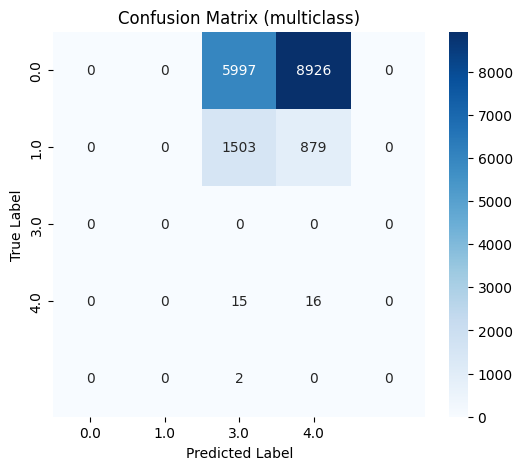

>> Multi-class Classification Balanced Accuracy: 0.1290


In [26]:

print("\n>> Evaluating Multi-class Classification Model...")
acc_multiclass = evaluate_best_model(best_multiclass, X_test, y_test_multi, "multiclass")
print(f">> Multi-class Classification Balanced Accuracy: {acc_multiclass:.4f}")

In [27]:
# Run GP for Binary Classification
print("\n>> Running GP Evolution for Binary Classification...")
toolbox.unregister("evaluate")
toolbox.register("evaluate", evalGP, X_train=X_train, y_train=y_train_bin, mode="binary")
best_binary, stats_binary = run_gp(X_train, y_train_bin, mode="binary")
print("\n>> Best GP Individual for Binary Classification:")
print(best_binary)


>> Running GP Evolution for Binary Classification...

>> Starting GP Evolution for BINARY Classification...

>> Population initialized with 10 individuals.
>> Running evolution for 50 generations...

>>> Generation 1/50
>>> Best Individual (Gen 1): sub(min(mul(mul(min(mul(X8, X44), add(X16, X10)), mul(sub(X28, X7), min(X37, X58))), add(safeDiv(mul(X2, X16), sub(X9, X47)), max(mul(X28, X63), sub(X10, X19)))), min(safeDiv(add(max(X15, X29), max(X29, X47)), min(min(X66, X21), min(X25, X28))), min(add(min(X23, X32), add(X28, X12)), mul(safeDiv(X57, X61), max(X55, X5))))), max(sub(sub(add(sub(X7, X8), safeDiv(X16, X8)), mul(mul(X63, X9), max(X40, X43))), sub(sub(sub(X12, X63), min(X54, X69)), min(safeDiv(X0, X26), mul(X41, X46)))), add(sub(add(add(X5, X65), min(X61, X62)), max(max(X54, X53), add(X11, X20))), add(safeDiv(min(X31, X52), max(X10, X38)), sub(mul(X44, X4), sub(X13, X28)))))), Fitness: 0.5001
>>> Crossover Applied
>>> Mutation Applied
>>> Best Fitness (Gen 1): 0.5003
>>> Generat

/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


>>> Best Fitness (Gen 2): 0.5945
>>> Generation 3/50


/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


>>> Best Individual (Gen 3): sub(min(mul(mul(min(mul(X8, X44), add(X16, X10)), mul(sub(X28, X7), min(X37, X58))), add(safeDiv(mul(X2, X16), sub(X9, X47)), max(mul(sub(X18, X4), X63), sub(X10, X19)))), min(safeDiv(add(max(X15, X29), max(X29, X47)), min(min(X66, X21), min(X25, X28))), min(add(min(X23, X32), add(X28, X12)), mul(safeDiv(X57, X61), max(X55, X5))))), max(sub(sub(add(sub(X7, X8), safeDiv(X16, X8)), mul(mul(X63, X9), max(X40, X43))), sub(sub(sub(X12, X63), min(X54, X69)), min(safeDiv(X0, X26), mul(X41, X46)))), add(sub(add(add(X5, X65), min(X61, X62)), max(max(X54, X53), add(X11, X20))), add(safeDiv(safeDiv(max(X25, X19), max(X16, X48)), max(X10, X38)), sub(mul(X44, X4), sub(X13, X28)))))), Fitness: 0.5945
>>> Crossover Applied
>>> Mutation Applied


...

>>> Best Fitness (Gen 49): 0.7991
>>> Generation 50/50


/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
 

>>> Best Individual (Gen 50): sub(min(mul(mul(min(mul(X8, X44), add(X16, X10)), max(max(X47, X15), add(X0, X28))), mul(max(X39, X4), add(X27, X23))), min(safeDiv(add(max(X15, X29), X26), min(min(X66, X21), max(X54, X53))), min(add(add(sub(X7, mul(X41, min(max(X66, X53), mul(X38, X50)))), sub(safeDiv(add(add(add(X6, X60), min(X40, X54)), sub(mul(X25, X43), safeDiv(X48, X1))), add(mul(min(X24, X25), sub(X21, X26)), max(min(X15, X62), mul(X14, X57)))), X8)), add(X28, X12)), mul(safeDiv(X57, X61), max(X55, X5))))), max(sub(sub(add(sub(X7, X8), sub(safeDiv(add(add(add(X6, X60), min(X40, X54)), sub(mul(X25, X43), safeDiv(X48, X1))), add(mul(min(X24, X25), sub(X21, X26)), max(min(X15, X62), mul(X14, X57)))), X8)), mul(mul(X63, X9), X38)), sub(sub(sub(X12, X63), min(X54, X69)), min(safeDiv(X0, X26), mul(X41, min(max(X66, X53), mul(X38, X50)))))), add(sub(add(add(X5, X20), min(X61, X62)), max(max(X54, X53), add(X11, X20))), add(safeDiv(safeDiv(add(safeDiv(safeDiv(safeDiv(safeDiv(sub(sub(sub(X12

/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
/tmp/ipykernel_8291/2588963373.py:16: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


>>> Best Fitness (Gen 50): 0.7991

>> Evolution Completed!

>> Best GP Individual After Evolution:
sub(min(mul(mul(min(mul(X8, X44), add(X16, X10)), max(max(X47, X15), add(X0, X28))), mul(max(X39, X4), add(X27, X23))), min(safeDiv(add(max(X15, X29), X26), min(min(X66, X21), max(X54, X53))), min(add(add(sub(X7, mul(X41, min(max(X66, X53), mul(X38, X50)))), sub(safeDiv(add(add(add(X6, X60), min(X40, X54)), sub(mul(X8, X43), safeDiv(X48, X1))), add(mul(min(X24, X25), sub(X21, X26)), max(min(X15, X62), mul(X14, X57)))), X8)), add(X28, X12)), mul(safeDiv(X57, X61), max(X55, X5))))), max(sub(sub(add(sub(X7, X8), sub(safeDiv(add(add(add(X6, X60), min(X40, X54)), sub(mul(X25, X43), safeDiv(X48, X1))), add(mul(min(X24, X25), sub(X21, X26)), max(min(X15, X62), mul(X14, X57)))), X8)), mul(mul(X63, X9), X38)), sub(sub(sub(X12, X63), min(X54, X69)), min(safeDiv(X0, X26), mul(X41, min(max(X66, X53), mul(X38, X50)))))), add(sub(add(add(X5, X20), min(X61, X62)), max(max(X54, X53), add(X11, X20))), add


>> Step 4: Evaluating the Evolved Models on Test Data...


>> Evaluating Binary Classification Model...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     12323
           1       0.48      1.00      0.65      5015

    accuracy                           0.69     17338
   macro avg       0.74      0.78      0.69     17338
weighted avg       0.85      0.69      0.70     17338



/tmp/ipykernel_15817/1755119027.py:5: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


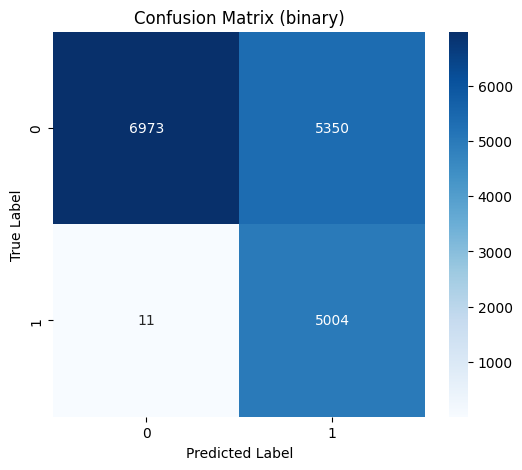

>> Binary Classification Balanced Accuracy: 0.7818


In [139]:
print("\n>> Step 4: Evaluating the Evolved Models on Test Data...\n")

print("\n>> Evaluating Binary Classification Model...")
acc_binary = evaluate_best_model(best_binary, X_test, y_test_bin, "binary")
print(f">> Binary Classification Balanced Accuracy: {acc_binary:.4f}")

print("\n>> Evaluating Multi-class Classification Model...")
acc_multiclass = evaluate_best_model(best_multiclass, X_test, y_test_multi, "multiclass")
print(f">> Multi-class Classification Balanced Accuracy: {acc_multiclass:.4f}")


>> Step 4: Evaluating the Evolved Models on Test Data...


>> Evaluating Binary Classification Model...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     12323
           1       0.48      1.00      0.65      5015

    accuracy                           0.69     17338
   macro avg       0.74      0.78      0.69     17338
weighted avg       0.85      0.69      0.70     17338



/tmp/ipykernel_15817/1755119027.py:5: RuntimeWarning: overflow encountered in exp
  y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))


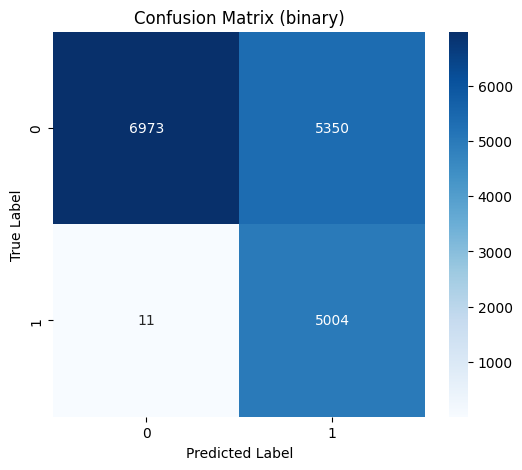

>> Binary Classification Balanced Accuracy: 0.7818


In [139]:
print("\n>> Step 4: Evaluating the Evolved Models on Test Data...\n")

print("\n>> Evaluating Binary Classification Model...")
acc_binary = evaluate_best_model(best_binary, X_test, y_test_bin, "binary")
print(f">> Binary Classification Balanced Accuracy: {acc_binary:.4f}")

print("\n>> Evaluating Multi-class Classification Model...")
acc_multiclass = evaluate_best_model(best_multiclass, X_test, y_test_multi, "multiclass")
print(f">> Multi-class Classification Balanced Accuracy: {acc_multiclass:.4f}")

In [1]:
print("\n>> Step 5: Running Simple Alert System (for Binary Detection)...\n")
alert_system(best_binary, X_test)


>> Step 5: Running Simple Alert System (for Binary Detection)...



NameError: name 'alert_system' is not defined

In [138]:
print("\n>> Step 5: Running Simple Alert System (for Multi-class Detection)...\n")
alert_system(best_multiclass, X_test)


>> Step 5: Running Simple Alert System (for Multi-class Detection)...



NameError: name 'best_multiclass' is not defined

In [29]:
df["Multiclass_Label"].value_counts()

Multiclass_Label
0.0    61912
1.0    11909
3.0      137
4.0       15
Name: count, dtype: int64

In [30]:
# Print the distribution of the Stage column
print("\n>> Distribution of Stage Column:")
print(df["Stage"].value_counts())


>> Distribution of Stage Column:
Stage
Benign                61912
Reconnaissance        11909
Establish Foothold     8604
Lateral Movement        137
Data Exfiltration        15
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Dropout, Attention, Add, Flatten, Reshape, LeakyReLU, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

seed_value = 42
np.random.seed(seed_value)

data = pd.read_csv('/content/drive/MyDrive/SWAT-Dataset/BinaryClass/SWaT_Dataset_Attack_v0.csv')
data['Normal/Attack'] = data['Normal/Attack'].replace('A ttack', 'Attack')
data['Normal/Attack'] = LabelEncoder().fit_transform(data['Normal/Attack'])

X = data.drop(columns=['Normal/Attack', ' Timestamp'], axis=1)
Y = data['Normal/Attack']

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_temp, Y_train, Y_temp = train_test_split(X_normalized, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

def build_generator(input_dim, output_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(output_dim, activation='tanh'))
    return model

def build_discriminator(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128)(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)
    x = Dense(64)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

def build_dense_model(input_shape, use_attention=False):
    inputs = Input(shape=input_shape)

    x = Dense(128, activation="relu")(inputs)
    x = Dropout(0.1)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.05)(x)

    if use_attention:
        reshaped = Reshape((-1, 1))(x)
        attention_output = Attention()([reshaped, reshaped])
        x = Flatten()(attention_output)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

def compile_gan(generator, discriminator):
    discriminator.compile(optimizer=Adam(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])
    discriminator.trainable = False

    gan_input = Input(shape=(generator.input_shape[1],))
    gan_output = discriminator(generator(gan_input))
    gan = Model(gan_input, gan_output)
    gan.compile(optimizer=Adam(learning_rate=0.0002), loss='binary_crossentropy')
    return gan

def train_gan(generator, discriminator, gan, X_train, epochs=100, batch_size=256):
    half_batch = batch_size // 2

    for epoch in range(epochs):
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_samples = X_train[idx]
        fake_samples = generator.predict(np.random.randn(half_batch, generator.input_shape[1]))

        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)

        noise = np.random.randn(batch_size, generator.input_shape[1])
        gan_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch == 0:
            print("Debugging Output of train_on_batch:")
            print(f"d_loss_real: {d_loss_real}")
            print(f"d_loss_fake: {d_loss_fake}")
            print(f"gan_loss: {gan_loss}")


        d_loss_real_loss = d_loss_real[0] if isinstance(d_loss_real, (list, tuple)) else d_loss_real
        d_loss_fake_loss = d_loss_fake[0] if isinstance(d_loss_fake, (list, tuple)) else d_loss_fake
        gan_loss_value = gan_loss[0] if isinstance(gan_loss, (list, tuple)) else gan_loss

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}: "
                  f"D_loss_real_loss={d_loss_real_loss:.4f}, "
                  f"D_loss_fake_loss={d_loss_fake_loss:.4f}, "
                  f"GAN_loss={gan_loss_value:.4f}")

def evaluate_with_confusion_matrix(model, X_test, Y_test, model_name):
    Y_pred_prob = model.predict(X_test)
    Y_pred = (Y_pred_prob > 0.5).astype(int)
    print(f"Classification Report - {model_name}")
    print(classification_report(Y_test, Y_pred))

    cm = confusion_matrix(Y_test, Y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

input_dim = X_train.shape[1]
generator = build_generator(input_dim=100, output_dim=input_dim)
discriminator = build_discriminator(input_dim=input_dim)
gan = compile_gan(generator, discriminator)

train_gan(generator, discriminator, gan, X_train, epochs=200, batch_size=256)

attention_model = build_dense_model(input_shape=(input_dim,), use_attention=True)
attention_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
attention_model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=256, verbose=1)

non_attention_model = build_dense_model(input_shape=(input_dim,), use_attention=False)
non_attention_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
non_attention_model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=256, verbose=1)

evaluate_with_confusion_matrix(attention_model, X_test, Y_test, "Attention-Based Model")
evaluate_with_confusion_matrix(non_attention_model, X_test, Y_test, "Non-Attention Model")